# Submission: Membangun Proyek Machine Learning
## Segmentasi Transaksi Finansial (K-Means) + Klasifikasi Ulang (Decision Tree)

**Dataset:** `data/fraud_transactions.csv`: data transaksi finansial sintetis (seeded, reproducible)
dengan kolom ID/Address/Date (`TransactionID`, `AccountID`, `DeviceID`, `IPAddress`,
`MerchantID`, `TransactionDate`), fitur numerik perilaku transaksi, dan fitur kategorikal.

**Alur notebook:**
- **Kriteria 1**: EDA: `head()`, `info()`, `describe()`
- **Kriteria 2**: Cleaning & preprocessing: `isnull().sum()`, `duplicated().sum()`, `dropna()`, `drop_duplicates()`, drop kolom ID/Address/Date, `LabelEncoder()`
- **Kriteria 3**: Clustering: `KElbowVisualizer()`, `KMeans`, `joblib.dump()` → `model_clustering`
- **Kriteria 4**: Interpretasi: agregasi `mean`/`min`/`max` per cluster, karakteristik tiap cluster, ekspor CSV + kolom `Target`
- **Kriteria 5**: Klasifikasi: `train_test_split()`, Decision Tree, `joblib.dump()` → `decision_tree_model.h5`


In [1]:
# Shim kompatibilitas: yellowbrick 1.5 mengimpor `distutils` yang sudah dihapus
# dari stdlib Python 3.12+. Arahkan ke implementasi setuptools (sudah terinstal).
import sys
import setuptools._distutils as _du
import setuptools._distutils.version as _duv
sys.modules.setdefault("distutils", _du)
sys.modules.setdefault("distutils.version", _duv)

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
KMeans._estimator_type = 'clusterer'  # kompatibilitas: sklearn>=1.6 menghapus _estimator_type yg dicek yellowbrick
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from yellowbrick.cluster import KElbowVisualizer

%matplotlib inline

print("pandas:", pd.__version__)
import sklearn, yellowbrick
print("scikit-learn:", sklearn.__version__)
print("yellowbrick:", yellowbrick.__version__)
print("joblib:", joblib.__version__)


pandas: 3.0.6
scikit-learn: 1.9.1
yellowbrick: 1.5
joblib: 1.6.0


## Kriteria 1: Memuat Dataset dan Exploratory Data Analysis (EDA)

In [2]:
# Kriteria 1a: memuat dataset dan menampilkannya dengan head()
df = pd.read_csv("data/fraud_transactions.csv")
print("Shape dataset:", df.shape)
df.head()


Shape dataset: (3045, 17)


,TransactionID,AccountID,DeviceID,IPAddress,MerchantID,TransactionDate,TransactionAmount,AccountAgeDays,NumTransactionsLast7D,AvgTransactionAmount7D,TransactionHour,BalanceBefore,BalanceAfter,TransactionType,MerchantCategory,DeviceType,Location
0,TXN001287,ACC00007,DEV00445,7.128.125.58,MER0137,2024-11-01 21:47:00,24.70,850,16,18.25,21,9578.67,9553.97,Purchase,Food,Mobile,Medan
1,TXN000643,ACC00500,DEV00073,235.148.229.91,MER0055,2024-01-04 13:42:00,11.60,681,15,8.25,13,3178.36,3166.76,Payment,Grocery,Mobile,Jakarta
2,TXN001147,ACC00601,DEV00106,108.61.3.198,MER0039,2024-02-17 02:49:00,221.83,316,5,169.53,2,1668.02,1446.19,Transfer,Fashion,Mobile,Bandung
3,TXN001279,ACC00555,DEV00069,229.18.149.207,MER0126,2024-03-13 03:48:00,396.46,51,3,373.11,3,5947.21,5550.75,Transfer,Travel,Mobile,Medan
4,TXN001940,ACC00019,DEV00461,18.5.53.72,MER0154,2024-05-22 08:11:00,15.24,1076,8,15.15,8,6825.49,6810.25,Payment,Grocery,Desktop,Bandung


In [3]:
# Kriteria 1b: informasi dataset dengan info()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3045 entries, 0 to 3044
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TransactionID           3045 non-null   str    
 1   AccountID               3045 non-null   str    
 2   DeviceID                3045 non-null   str    
 3   IPAddress               3045 non-null   str    
 4   MerchantID              3045 non-null   str    
 5   TransactionDate         3045 non-null   str    
 6   TransactionAmount       3045 non-null   float64
 7   AccountAgeDays          3045 non-null   int64  
 8   NumTransactionsLast7D   3045 non-null   int64  
 9   AvgTransactionAmount7D  2982 non-null   float64
 10  TransactionHour         3045 non-null   int64  
 11  BalanceBefore           3045 non-null   float64
 12  BalanceAfter            3045 non-null   float64
 13  TransactionType         3045 non-null   str    
 14  MerchantCategory        2985 non-null   str    
 15

In [4]:
# Kriteria 1c: statistik deskriptif dengan describe()
print("=== Statistik deskriptif (numerik) ===")
display(df.describe().T)
print("\n=== Statistik deskriptif (kategorikal) ===")
display(df.describe(include="object").T)


=== Statistik deskriptif (numerik) ===


,count,mean,std,min,25%,50%,75%,max
TransactionAmount,3045.0,295.205468,453.919694,6.26,32.7900,97.500,345.4700,4285.90
AccountAgeDays,3045.0,989.796388,829.839867,1.00,261.0000,812.000,1477.0000,2995.00
NumTransactionsLast7D,3045.0,7.601970,5.126763,0.00,3.0000,7.000,12.0000,27.00
AvgTransactionAmount7D,2982.0,265.177257,414.238991,4.39,29.3025,89.985,302.1475,4342.38
TransactionHour,3045.0,11.031199,6.784704,0.00,5.0000,11.000,17.0000,23.00
BalanceBefore,3045.0,6784.764631,6745.157756,303.11,2857.5300,4803.020,8279.3000,86793.06
BalanceAfter,3045.0,6489.559163,6757.356617,-1855.50,2538.3800,4537.960,7967.5000,86758.19



=== Statistik deskriptif (kategorikal) ===


C:\Users\USER\AppData\Local\Temp\ipykernel_30360\1973631042.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
TransactionID,3045,3000,TXN000638,2
AccountID,3045,778,ACC00480,11
DeviceID,3045,499,DEV00158,13
IPAddress,3045,3000,70.61.216.68,2
MerchantID,3045,199,MER0062,28
TransactionDate,3045,2989,2024-08-11 08:11:00,2
TransactionType,3045,4,Purchase,1092
MerchantCategory,2985,5,Travel,787
DeviceType,3045,3,Mobile,1962
Location,3045,5,Surabaya,630


## Kriteria 2: Pembersihan dan Pra Pemrosesan Data

In [5]:
# Kriteria 2a: cek missing value dan data duplikat
print("=== Missing value per kolom ===")
print(df.isnull().sum())
print("\nTotal missing:", int(df.isnull().sum().sum()))
print("\nJumlah baris duplikat:", int(df.duplicated().sum()))


=== Missing value per kolom ===
TransactionID              0
AccountID                  0
DeviceID                   0
IPAddress                  0
MerchantID                 0
TransactionDate            0
TransactionAmount          0
AccountAgeDays             0
NumTransactionsLast7D      0
AvgTransactionAmount7D    63
TransactionHour            0
BalanceBefore              0
BalanceAfter               0
TransactionType            0
MerchantCategory          60
DeviceType                 0
Location                   0
dtype: int64

Total missing: 123

Jumlah baris duplikat: 45


In [6]:
# Kriteria 2b: tangani missing value dengan dropna()
print("Shape sebelum dropna:", df.shape)
df_clean = df.dropna()
print("Shape setelah dropna:", df_clean.shape,
      "| baris dibuang:", df.shape[0] - df_clean.shape[0])

# Kriteria 2c: hapus duplikat dengan drop_duplicates()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape setelah drop_duplicates:", df_clean.shape)
print("Sisa missing:", int(df_clean.isnull().sum().sum()))
print("Sisa duplikat:", int(df_clean.duplicated().sum()))


Shape sebelum dropna: (3045, 17)
Shape setelah dropna: (2922, 17) | baris dibuang: 123
Shape setelah drop_duplicates: (2880, 17)
Sisa missing: 0
Sisa duplikat: 0


In [7]:
# Kriteria 2d: drop kolom ID / Address / Date
drop_cols = ["TransactionID", "AccountID", "DeviceID",
             "IPAddress", "MerchantID", "TransactionDate"]
df_model = df_clean.drop(columns=drop_cols)
print("Kolom yang di-drop:", drop_cols)
print("Kolom tersisa:", list(df_model.columns))
print("Shape data modeling:", df_model.shape)


Kolom yang di-drop: ['TransactionID', 'AccountID', 'DeviceID', 'IPAddress', 'MerchantID', 'TransactionDate']
Kolom tersisa: ['TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter', 'TransactionType', 'MerchantCategory', 'DeviceType', 'Location']
Shape data modeling: (2880, 11)


In [8]:
# Kriteria 2e: feature encoding dengan LabelEncoder() untuk fitur kategorikal
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
print("Fitur kategorikal:", cat_cols)

encoders = {}
df_encoded = df_model.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

print("\nContoh mapping (TransactionType):",
      dict(zip(encoders["TransactionType"].classes_,
               encoders["TransactionType"].transform(encoders["TransactionType"].classes_))))
df_encoded.head()


Fitur kategorikal: ['TransactionType', 'MerchantCategory', 'DeviceType', 'Location']

Contoh mapping (TransactionType): {'Payment': np.int64(0), 'Purchase': np.int64(1), 'Transfer': np.int64(2), 'Withdrawal': np.int64(3)}


C:\Users\USER\AppData\Local\Temp\ipykernel_30360\581464685.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include="object").columns.tolist()


,TransactionAmount,AccountAgeDays,NumTransactionsLast7D,AvgTransactionAmount7D,TransactionHour,BalanceBefore,BalanceAfter,TransactionType,MerchantCategory,DeviceType,Location
0,24.70,850,16,18.25,21,9578.67,9553.97,1,2,1,3
1,11.60,681,15,8.25,13,3178.36,3166.76,0,3,1,2
2,221.83,316,5,169.53,2,1668.02,1446.19,2,1,1,0
3,396.46,51,3,373.11,3,5947.21,5550.75,2,4,1,3
4,15.24,1076,8,15.15,8,6825.49,6810.25,0,3,0,0


In [9]:
# Standardisasi fitur numerik agar K-Means tidak didominasi fitur berskala besar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
print("Shape X_scaled:", X_scaled.shape)


Shape X_scaled: (2880, 11)


## Kriteria 3: Membangun Model Clustering

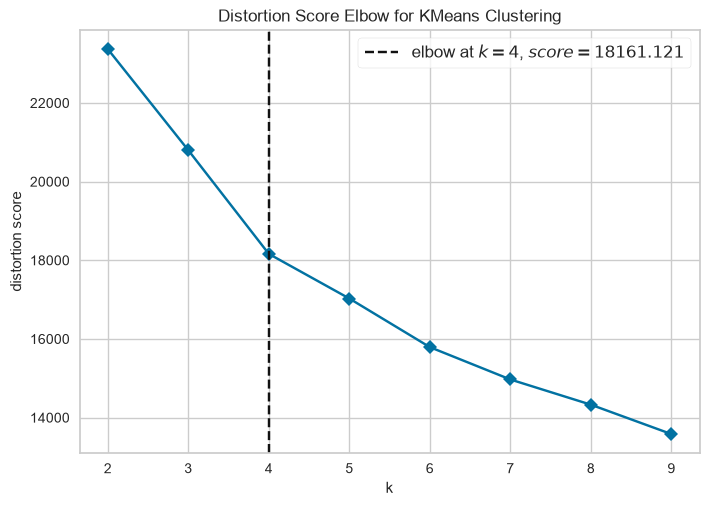

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [10]:
# Kriteria 3a: Elbow Method dengan KElbowVisualizer() untuk jumlah cluster terbaik
base_model = KMeans(random_state=42)
visualizer = KElbowVisualizer(base_model, k=(2, 10), metric="distortion", timings=False)
visualizer.fit(X_scaled)
visualizer.show()


In [11]:
# Kriteria 3b: K-Means Clustering dengan jumlah cluster terbaik
k_optimal = visualizer.elbow_value_
if k_optimal is None:
    k_optimal = 3  # fallback bila siku tidak terdeteksi otomatis
k_optimal = int(k_optimal)
print("Jumlah cluster terbaik (elbow):", k_optimal)

kmeans = KMeans(n_clusters=k_optimal, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
print("\nDistribusi anggota tiap cluster:")
print(pd.Series(clusters, name="cluster").value_counts().sort_index())
print("\nInertia:", round(kmeans.inertia_, 2))


Jumlah cluster terbaik (elbow): 4

Distribusi anggota tiap cluster:
cluster
0    1016
1     548
2     189
3    1127
Name: count, dtype: int64

Inertia: 18161.03


In [12]:
# Kriteria 3c: simpan model clustering dengan joblib.dump() bernama model_clustering
joblib.dump(kmeans, "model_clustering.pkl")
joblib.dump(kmeans, "model_clustering")  # alias tanpa ekstensi, sesuai penamaan kriteria
print("Model clustering tersimpan: model_clustering.pkl & model_clustering")
print("Tipe objek:", type(joblib.load("model_clustering.pkl")))


Model clustering tersimpan: model_clustering.pkl & model_clustering
Tipe objek: <class 'sklearn.cluster._kmeans.KMeans'>


## Kriteria 4: Interpretasi Hasil Clustering

In [13]:
# Kriteria 4a: analisis deskriptif (mean, min, max) fitur numerik per cluster
df_clustered = df_encoded.copy()
df_clustered["Target"] = clusters

num_features = df_encoded.select_dtypes(include="number").columns.tolist()
agg = df_clustered.groupby("Target")[num_features].agg(["mean", "min", "max"]).round(2)
display(agg)

print("\nUkuran tiap cluster:")
print(df_clustered["Target"].value_counts().sort_index())


TransactionAmount                  AccountAgeDays             \
                    mean     min      max           mean  min   max   
Target                                                                
0                 197.46   11.81   844.47         655.00   20  2425   
1                1037.79  264.35  4285.90         100.78    1  1197   
2                 174.30    6.26  1442.01        1064.63   12  2932   
3                  38.96    6.33   456.27        1727.66  209  2995   

       NumTransactionsLast7D         AvgTransactionAmount7D  ...  \
                        mean min max                   mean  ...   
Target                                                       ...   
0                       5.19   0  15                 176.45  ...   
1                       1.93   0   9                 927.96  ...   
2                       8.04   0  20                 159.55  ...   
3                      12.52   3  27                  35.31  ...   

       TransactionType MerchantCategory         DeviceType         Location  \
                   max             mean min max       mean min max     mean   
Target                                                                        
0                    3             1.76   0   4       0.77   0   2     1.95   
1                    3             2.55   0   4       0.41   0   2     1.97   
2                    3             2.22   0   4       0.78   0   2     2.02   
3                    2             2.38   0   4       0.87   0   2     2.12   

                
       min max  
Target          
0        0   4  
1        0   4  
2        0   4  
3        0   4  

[4 rows x 33 columns]


Ukuran tiap cluster:
Target
0    1016
1     548
2     189
3    1127
Name: count, dtype: int64


In [14]:
# Ringkasan perilaku utama tiap cluster (rata-rata)
summary = df_clustered.groupby("Target")[
    ["TransactionAmount", "AccountAgeDays", "NumTransactionsLast7D",
     "AvgTransactionAmount7D", "TransactionHour"]
].mean().round(2)
display(summary)

for cl, row in summary.iterrows():
    print(f"Cluster {cl}: amount={row['TransactionAmount']}, umur_akun={row['AccountAgeDays']} hari, "
          f"frekuensi_7d={row['NumTransactionsLast7D']}, jam={row['TransactionHour']}")


,TransactionAmount,AccountAgeDays,NumTransactionsLast7D,AvgTransactionAmount7D,TransactionHour
Target,,,,,
0,197.46,655.00,5.19,176.45,11.26
1,1037.79,100.78,1.93,927.96,2.50
2,174.30,1064.63,8.04,159.55,12.00
3,38.96,1727.66,12.52,35.31,14.82


Cluster 0: amount=197.46, umur_akun=655.0 hari, frekuensi_7d=5.19, jam=11.26
Cluster 1: amount=1037.79, umur_akun=100.78 hari, frekuensi_7d=1.93, jam=2.5
Cluster 2: amount=174.3, umur_akun=1064.63 hari, frekuensi_7d=8.04, jam=12.0
Cluster 3: amount=38.96, umur_akun=1727.66 hari, frekuensi_7d=12.52, jam=14.82


### Karakteristik tiap cluster (berdasarkan tabel agregasi di atas)

| Cluster | Ukuran | Ciri utama | Interpretasi |
|---|---|---|---|
| **0** | 1016 | `TransactionAmount` menengah (~197, maks ~844), `AccountAgeDays` sedang (~655 hari), frekuensi sedang (~5,2 trx/7 hari), jam pagi-siang (~11) | **Segmen menengah-aktif**: transaksi moderat dengan ritme wajar; kandidat upsell dengan monitoring standar. |
| **1** | 548 | `TransactionAmount` tertinggi (~1038, maks >4200), `AccountAgeDays` termuda (~101 hari, min 1 hari), frekuensi terendah (~1,9 trx/7 hari), jam dini hari (~02-03) | **Segmen berisiko / anomali**: transaksi besar dari akun muda, jarang bertransaksi, di jam tidak wajar. Prioritas monitoring fraud. |
| **2** | 189 | `TransactionAmount` menengah (~174, maks ~1442), akun mapan (~1065 hari), frekuensi sedang-tinggi (~8,0 trx/7 hari), jam normal (~12) | **Segmen menengah-mapan**: perilaku mirip reguler tapi nilai lebih tinggi; monitor ringan + peluang cross-sell. |
| **3** | 1127 (mayoritas) | `TransactionAmount` terkecil (~39, maks ~456), akun paling lama (~1728 hari), frekuensi tertinggi (~12,5 trx/7 hari), jam normal siang (~14-15) | **Pelanggan reguler / loyal**: transaksi kecil-rutin dari akun mapan di jam wajar. Segmen sehat terbesar. |

Catatan: nomor label cluster bersifat arbitrer (artefak K-Means); pemaknaan didasarkan
pada profil agregat `mean`/`min`/`max`, bukan pada angka labelnya.


In [15]:
# Kriteria 4c: ekspor data training hasil preprocessing + hasil clustering (kolom "Target")
df_clustered.to_csv("training_with_target.csv", index=False)
print("Tersimpan: training_with_target.csv", df_clustered.shape)
print("Kolom:", list(df_clustered.columns))


Tersimpan: training_with_target.csv (2880, 12)
Kolom: ['TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter', 'TransactionType', 'MerchantCategory', 'DeviceType', 'Location', 'Target']


## Kriteria 5: Membangun Model Klasifikasi

In [16]:
# Kriteria 5a: pembagian dataset dengan train_test_split()
X = df_clustered.drop(columns=["Target"])
y = df_clustered["Target"]  # target = hasil clustering (Kriteria 4)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Distribusi label train:\n", y_train.value_counts(normalize=True).round(3))
print("Distribusi label test:\n", y_test.value_counts(normalize=True).round(3))


X_train: (2304, 11) | X_test: (576, 11)
Distribusi label train:
 Target
3    0.391
0    0.353
1    0.190
2    0.066
Name: proportion, dtype: float64
Distribusi label test:
 Target
3    0.391
0    0.352
1    0.191
2    0.066
Name: proportion, dtype: float64


In [17]:
# Kriteria 5b: model Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("Akurasi test:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


Akurasi test: 0.9323

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       203
           1       0.96      0.96      0.96       110
           2       0.97      0.92      0.95        38
           3       0.94      0.92      0.93       225

    accuracy                           0.93       576
   macro avg       0.94      0.93      0.94       576
weighted avg       0.93      0.93      0.93       576

Confusion matrix:
[[188   4   0  11]
 [  4 106   0   0]
 [  1   0  35   2]
 [ 16   0   1 208]]


In [18]:
# Kriteria 5c: simpan model dengan joblib.dump() bernama decision_tree_model.h5
joblib.dump(dt, "decision_tree_model.h5")
print("Model klasifikasi tersimpan: decision_tree_model.h5")
print("Tipe objek:", type(joblib.load("decision_tree_model.h5")))


Model klasifikasi tersimpan: decision_tree_model.h5
Tipe objek: <class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [19]:
# Verifikasi akhir: kedua model termuat dan dapat memprediksi data baru
km_loaded = joblib.load("model_clustering.pkl")
dt_loaded = joblib.load("decision_tree_model.h5")

sample = X_test.iloc[:5]
print("Prediksi cluster (K-Means)     :", km_loaded.predict(scaler.transform(sample)))
print("Prediksi kelas (Decision Tree) :", dt_loaded.predict(sample))
print("Label aktual (Target)          :", y_test.iloc[:5].to_numpy())
print("\nSemua kriteria 1-5 selesai dan terverifikasi.")


Prediksi cluster (K-Means)     : [1 2 0 1 0]
Prediksi kelas (Decision Tree) : [1 2 0 1 0]
Label aktual (Target)          : [1 2 0 1 0]

Semua kriteria 1-5 selesai dan terverifikasi.
